# 1.3 Balance y desbalance de datos

## Objetivo
Aprender de forma sencilla qué es un **dataset balanceado y desbalanceado**, y aplicar tres técnicas básicas:

- **RUS:** submuestreo.
- **ROS:** sobremuestreo.
- **SMOTE:** creación de ejemplos sintéticos.

Al final compararemos **Accuracy, Precisión, Recall y matriz de confusión**.

> Los datos serán sintéticos: Python los creará automáticamente.


## 1. Librerías
Si `imblearn` no está instalado en Colab, descomenta la primera línea.

In [5]:
%pip install imbalanced-learn

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

print("Librerías listas")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]1/2 [imbalanced-learn]
Note: you may need to restart the kernel to use updated packages.
Librerías listas


## 2. Ejemplo de dataset balanceado
Crearemos **1,000 registros**. Aproximadamente la mitad pertenecerá a cada clase.

0    501
1    499
Name: count, dtype: int64


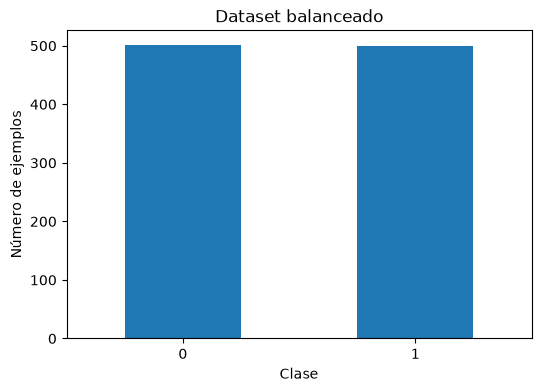

In [6]:
X_b, y_b = make_classification(
    n_samples=1000, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1,
    weights=[0.50, 0.50], random_state=42
)

conteo = pd.Series(y_b).value_counts().sort_index()
print(conteo)

conteo.plot(kind="bar", figsize=(6,4))
plt.title("Dataset balanceado")
plt.xlabel("Clase")
plt.ylabel("Número de ejemplos")
plt.xticks(rotation=0)
plt.show()


### ¿Qué observas?
Las barras tienen alturas parecidas. El modelo dispone de cantidades semejantes de ejemplos de ambas clases.

## 3. Dataset desbalanceado
Ahora crearemos aproximadamente:

- **900 ejemplos de Clase 0**
- **100 ejemplos de Clase 1**

La Clase 1 será la **clase minoritaria**.

Clase
0    895
1    105
Name: count, dtype: int64


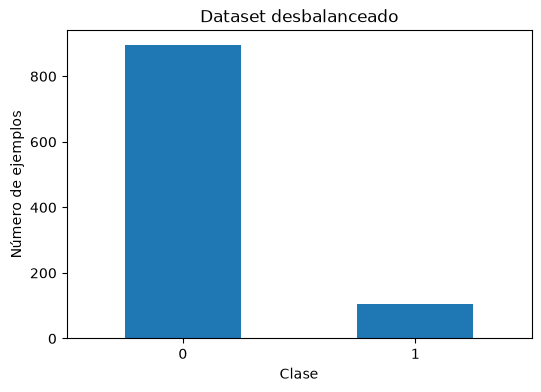

In [7]:
X, y = make_classification(
    n_samples=1000, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1,
    weights=[0.90, 0.10], class_sep=1.0,
    random_state=42
)

df = pd.DataFrame(X, columns=["Caracteristica_1", "Caracteristica_2"])
df["Clase"] = y

conteo_original = df["Clase"].value_counts().sort_index()
print(conteo_original)

conteo_original.plot(kind="bar", figsize=(6,4))
plt.title("Dataset desbalanceado")
plt.xlabel("Clase")
plt.ylabel("Número de ejemplos")
plt.xticks(rotation=0)
plt.show()


## 4. Porcentaje de balance

Una forma sencilla de observar el desbalance es:

**PB = (número de ejemplos de la clase minoritaria / total de ejemplos) × 100**

Ejemplo: si existen 100 casos minoritarios de 1,000 registros:

**PB = 100 / 1000 × 100 = 10 %**


In [8]:
minoritarios = conteo_original.min()
total = conteo_original.sum()
PB = minoritarios / total * 100

print("Clase minoritaria:", minoritarios)
print("Total:", total)
print(f"Porcentaje de balance: {PB:.2f}%")


Clase minoritaria: 105
Total: 1000
Porcentaje de balance: 10.50%


## 5. Veamos los puntos de ambas clases

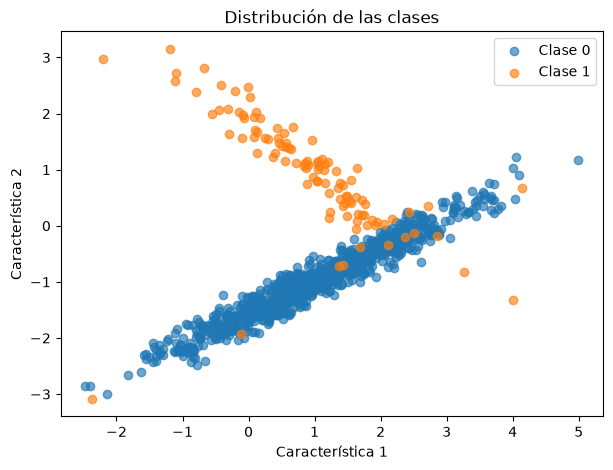

In [9]:
plt.figure(figsize=(7,5))

for clase in [0, 1]:
    datos = df[df["Clase"] == clase]
    plt.scatter(datos["Caracteristica_1"], datos["Caracteristica_2"],
                label=f"Clase {clase}", alpha=0.65)

plt.title("Distribución de las clases")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend()
plt.show()


## 6. Modelo SIN balancear
Usaremos **Regresión Logística**. Primero separamos:

- 80 % para entrenamiento.
- 20 % para prueba.

**Importante:** el conjunto de prueba no se balanceará.

Accuracy : 0.97
Precisión: 1.0
Recall   : 0.714


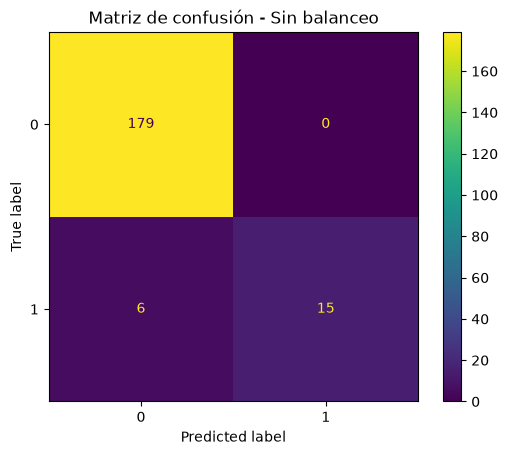

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

modelo = LogisticRegression()
modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, pred), 3))
print("Precisión:", round(precision_score(y_test, pred, zero_division=0), 3))
print("Recall   :", round(recall_score(y_test, pred, zero_division=0), 3))

ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.title("Matriz de confusión - Sin balanceo")
plt.show()


### ¿Por qué no basta con Accuracy?
Si casi todos los datos son de la Clase 0, un modelo puede obtener muchos aciertos simplemente aprendiendo muy bien esa clase.

Por eso también observamos **Precisión, Recall y la matriz de confusión**.

## 7. RUS — Submuestreo
**Random Under Sampling** elimina ejemplos de la clase mayoritaria.

Ejemplo: **900 : 100 → 100 : 100**

Ventaja: reduce rápidamente el desbalance.  
Cuidado: puede eliminar información útil.

In [11]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

print("Antes:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nDespués de RUS:")
print(pd.Series(y_rus).value_counts().sort_index())


Antes:
0    716
1     84
Name: count, dtype: int64

Después de RUS:
0    84
1    84
Name: count, dtype: int64


## 8. ROS — Sobremuestreo
**Random Over Sampling** aumenta la clase minoritaria repitiendo ejemplos.

Ejemplo: **900 : 100 → 900 : 900**

Ventaja: no elimina datos mayoritarios.  
Cuidado: repetir ejemplos puede favorecer el sobreajuste.

In [12]:
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)

print("Después de ROS:")
print(pd.Series(y_ros).value_counts().sort_index())


Después de ROS:
0    716
1    716
Name: count, dtype: int64


## 9. SMOTE
**SMOTE** aumenta la clase minoritaria de una manera diferente: genera **nuevos ejemplos sintéticos** tomando como referencia ejemplos minoritarios cercanos.

No se limita a copiar exactamente los registros existentes.

In [13]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

print("Después de SMOTE:")
print(pd.Series(y_smote).value_counts().sort_index())


Después de SMOTE:
0    716
1    716
Name: count, dtype: int64


## 10. Comparación de la cantidad de datos

,Método,Clase 0,Clase 1
0,Original,716,84
1,RUS,84,84
2,ROS,716,716
3,SMOTE,716,716


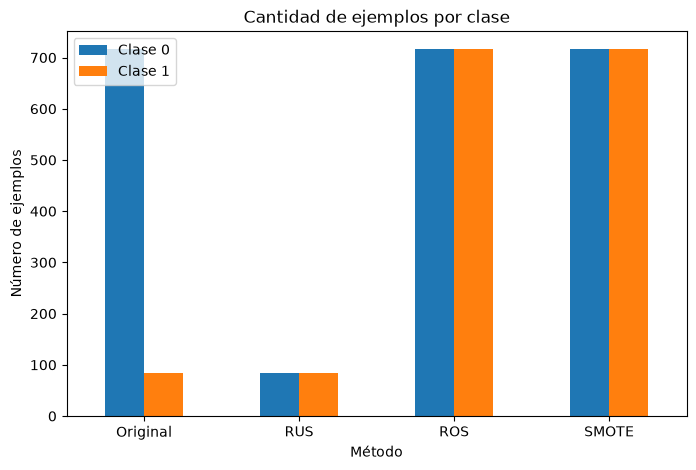

In [14]:
metodos = {
    "Original": y_train,
    "RUS": y_rus,
    "ROS": y_ros,
    "SMOTE": y_smote
}

filas = []
for nombre, etiquetas in metodos.items():
    c = pd.Series(etiquetas).value_counts().sort_index()
    filas.append([nombre, c.get(0,0), c.get(1,0)])

tabla_clases = pd.DataFrame(filas, columns=["Método","Clase 0","Clase 1"])
display(tabla_clases)

tabla_clases.set_index("Método").plot(kind="bar", figsize=(8,5))
plt.title("Cantidad de ejemplos por clase")
plt.ylabel("Número de ejemplos")
plt.xticks(rotation=0)
plt.show()


## 11. ¿Qué pasa con el modelo?
Entrenaremos el **mismo modelo** cuatro veces. Solo cambiaremos los datos de entrenamiento.

In [15]:
datasets = {
    "Sin balanceo": (X_train, y_train),
    "RUS": (X_rus, y_rus),
    "ROS": (X_ros, y_ros),
    "SMOTE": (X_smote, y_smote)
}

resultados = []
predicciones = {}

for nombre, (Xe, ye) in datasets.items():
    modelo = LogisticRegression()
    modelo.fit(Xe, ye)
    pred = modelo.predict(X_test)
    predicciones[nombre] = pred

    resultados.append([
        nombre,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, zero_division=0),
        recall_score(y_test, pred, zero_division=0)
    ])

tabla = pd.DataFrame(
    resultados,
    columns=["Método","Accuracy","Precisión","Recall"]
)

display(tabla.round(3))


,Método,Accuracy,Precisión,Recall
0,Sin balanceo,0.970,1.000,0.714
1,RUS,0.975,0.864,0.905
2,ROS,0.975,0.864,0.905
3,SMOTE,0.965,0.792,0.905


## 12. Gráfica final de métricas

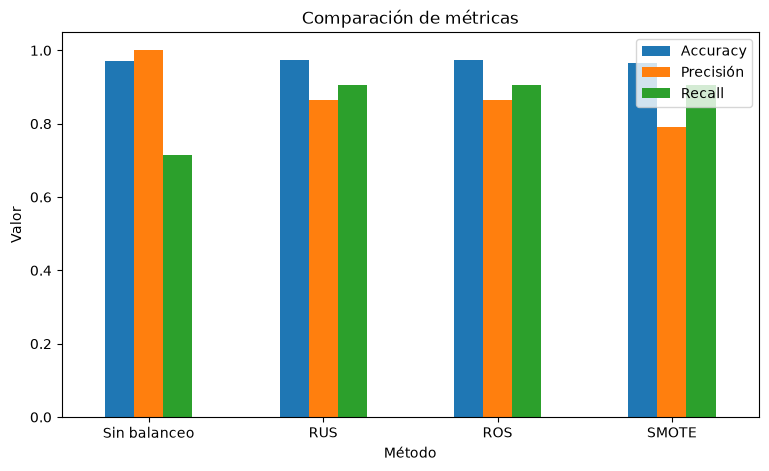

In [16]:
tabla.set_index("Método").plot(kind="bar", figsize=(9,5))
plt.title("Comparación de métricas")
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()


## 13. Matriz de confusión con SMOTE

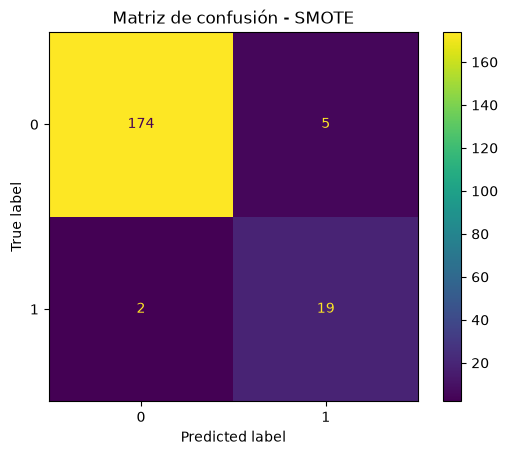

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, predicciones["SMOTE"])
plt.title("Matriz de confusión - SMOTE")
plt.show()


# 14. Conclusiones

- **Balanceado:** las clases tienen cantidades similares.
- **Desbalanceado:** una clase tiene muchos más ejemplos.
- **RUS:** elimina datos de la clase mayoritaria.
- **ROS:** repite datos de la clase minoritaria.
- **SMOTE:** genera ejemplos sintéticos de la clase minoritaria.
- Después de balancear debemos volver a revisar **Accuracy, Precisión, Recall y matriz de confusión**.
- El balanceo se aplica al **entrenamiento**, no al conjunto de prueba.

### Idea principal
**Balancear no garantiza automáticamente que el modelo sea mejor. Debemos comprobarlo con las métricas.**


# 15. Actividad sencilla

Cambia en la creación del dataset:

```python
weights=[0.95, 0.05]
```

Vuelve a ejecutar el notebook y responde:

1. ¿Cuántos ejemplos hay en cada clase?
2. ¿Cuál es el porcentaje de balance?
3. ¿Qué sucede con Accuracy, Precisión y Recall?
4. ¿Qué hace RUS?
5. ¿Qué hace ROS?
6. ¿Qué hace SMOTE?
7. ¿Cuál técnica mejora más el Recall en este ejemplo?
8. Explica en 5 líneas por qué el desbalance puede ser un problema.
